# Fixed Income & Yield Curve Analytics

This project turns the Financial Mathematics bond lecture into a compact fixed-income analytics workflow.

$$
\text{Bond Cash Flows}
\rightarrow
\text{Price / Yield}
\rightarrow
\text{Duration}
\rightarrow
\text{Convexity}
\rightarrow
\text{Treasury Yield Curve}
\rightarrow
\text{Forward Rates}
\rightarrow
\text{Nelson--Siegel}
\rightarrow
\text{Vasicek / CIR}
$$

**Real-market section:** U.S. Treasury constant-maturity yields from FRED.

> Educational quantitative-finance research only. Not investment advice.

## 1. Bond cash flows and pricing

A bond is a debt instrument that promises future cash flows.

For an annual coupon bond with face value $F$, annual coupon $C$, maturity $T$, and yield $y$,

$$
\boxed{P(y)=\sum_{t=1}^{T}\frac{C}{(1+y)^t}+\frac{F}{(1+y)^T}}
$$

The key relationship is:

$$
\boxed{\text{Yield rises} \Rightarrow \text{Bond price falls}}
$$

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

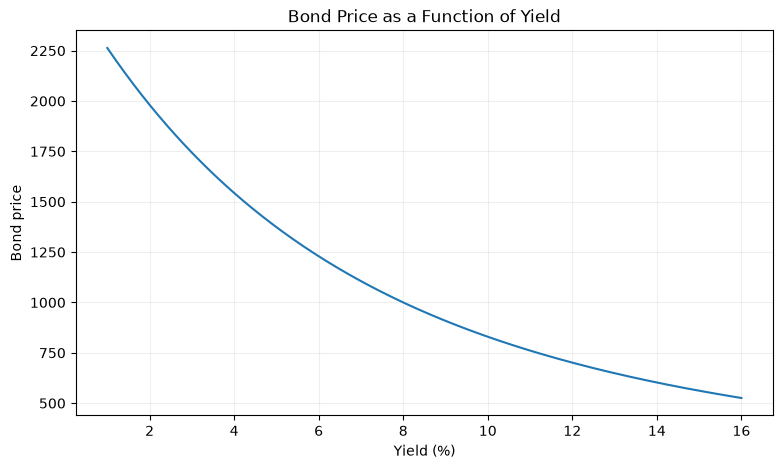

In [2]:
def bond_price(face, coupon_rate, maturity, yield_rate):
    coupon = face * coupon_rate
    times = np.arange(1, maturity + 1)
    cashflows = np.full(maturity, coupon, dtype=float)
    cashflows[-1] += face
    return float(np.sum(cashflows / (1 + yield_rate) ** times))

face = 1000
coupon_rate = 0.08
maturity = 20

yield_grid = np.linspace(0.01, 0.16, 300)
price_grid = [bond_price(face, coupon_rate, maturity, y) for y in yield_grid]

plt.figure(figsize=(9, 5))
plt.plot(100 * yield_grid, price_grid)
plt.title("Bond Price as a Function of Yield")
plt.xlabel("Yield (%)")
plt.ylabel("Bond price")
plt.grid(alpha=0.2)
plt.show()

## 2. Yield to Maturity and Newton--Raphson

Given the market price, the YTM is the value $y$ satisfying the bond-pricing equation.

Define

$$
f(y)=P_{\text{market}}-P(y).
$$

Newton--Raphson updates

$$
\boxed{y_{n+1}=y_n-\frac{f(y_n)}{f'(y_n)}}.
$$

In [3]:
def bond_price_derivative(face, coupon_rate, maturity, yield_rate):
    coupon = face * coupon_rate
    times = np.arange(1, maturity + 1)
    cashflows = np.full(maturity, coupon, dtype=float)
    cashflows[-1] += face
    return float(np.sum(-times * cashflows / (1 + yield_rate) ** (times + 1)))


def solve_ytm_newton(market_price, face, coupon_rate, maturity,
                     initial_guess=0.05, tol=1e-12, max_iter=100):
    y = float(initial_guess)
    for i in range(max_iter):
        model_price = bond_price(face, coupon_rate, maturity, y)
        f = market_price - model_price
        fp = -bond_price_derivative(face, coupon_rate, maturity, y)
        y_new = y - f / fp
        if abs(y_new - y) < tol:
            return y_new, i + 1
        y = y_new
    raise RuntimeError("Newton-Raphson did not converge.")

example_market_price = 950.0
yt, iterations = solve_ytm_newton(950.0, 1000, 0.06, 10, initial_guess=0.06)

pd.Series({
    "market_price": example_market_price,
    "estimated_ytm": yt,
    "iterations": iterations,
    "repriced_value": bond_price(1000, 0.06, 10, yt),
}).to_frame("value")

,value
market_price,950.000000
estimated_ytm,0.067021
iterations,4.000000
repriced_value,950.000000


## 3. Zero-coupon bonds and continuous discounting

For a zero-coupon bond,

$$
P(t,T)=Fe^{-y(t,T)(T-t)}
$$

so

$$
\boxed{y(t,T)=-\frac{\ln(P/F)}{T-t}}.
$$

For unit face value and a deterministic short rate,

$$
P(t,T)=\exp\left(-\int_t^T r(s)\,ds\right).
$$

In [4]:
def zero_coupon_price(face, continuous_yield, time_to_maturity):
    return face * np.exp(-continuous_yield * time_to_maturity)

def zero_coupon_yield(price, face, time_to_maturity):
    return -np.log(price / face) / time_to_maturity

zc_price = zero_coupon_price(100, 0.04, 5)
zc_yield = zero_coupon_yield(zc_price, 100, 5)

pd.Series({
    "zero_coupon_price": zc_price,
    "recovered_continuous_yield": zc_yield,
}).to_frame("value")

,value
zero_coupon_price,81.873075
recovered_continuous_yield,0.040000


## 4. Duration

Macaulay duration is

$$
\boxed{D=\frac{1}{P}\sum_{t=1}^{T}t\frac{CF_t}{(1+y)^t}}
$$

and modified duration is

$$
\boxed{D_m=\frac{D}{1+y}}.
$$

For a small yield change $\Delta y$,

$$
\boxed{\Delta P\approx-D_mP\Delta y}.
$$

In [5]:
def macaulay_duration(face, coupon_rate, maturity, yield_rate):
    coupon = face * coupon_rate
    times = np.arange(1, maturity + 1)
    cashflows = np.full(maturity, coupon, dtype=float)
    cashflows[-1] += face
    discounted = cashflows / (1 + yield_rate) ** times
    price = discounted.sum()
    return float(np.sum(times * discounted) / price)


def modified_duration(face, coupon_rate, maturity, yield_rate):
    return macaulay_duration(face, coupon_rate, maturity, yield_rate) / (1 + yield_rate)

pd.Series({
    "Macaulay_duration": macaulay_duration(1000, 0.04, 10, 0.08),
    "Modified_duration": modified_duration(1000, 0.04, 10, 0.08),
}).to_frame("value")

,value
Macaulay_duration,8.118422
Modified_duration,7.517058


## 5. Convexity

For larger yield movements, the second-order approximation is

$$
\boxed{\Delta P\approx-D_mP\Delta y+\frac12CP(\Delta y)^2}.
$$

For annual cash flows,

$$
\boxed{C=\frac{1}{P}\sum_{t=1}^{T}\frac{t(t+1)CF_t}{(1+y)^{t+2}}}.
$$

In [6]:
def convexity(face, coupon_rate, maturity, yield_rate):
    coupon = face * coupon_rate
    times = np.arange(1, maturity + 1)
    cashflows = np.full(maturity, coupon, dtype=float)
    cashflows[-1] += face
    P = bond_price(face, coupon_rate, maturity, yield_rate)
    C = np.sum(times * (times + 1) * cashflows / (1 + yield_rate) ** (times + 2)) / P
    return float(C)

face = 1000
coupon_rate = 0.04
maturity = 10
y0 = 0.08
P0 = bond_price(face, coupon_rate, maturity, y0)
Dm = modified_duration(face, coupon_rate, maturity, y0)
C = convexity(face, coupon_rate, maturity, y0)

rows=[]
for shock_bps in [-200, -100, -50, 50, 100, 200]:
    dy = shock_bps / 10000
    rows.append({
        "shock_bps": shock_bps,
        "exact_change": bond_price(face, coupon_rate, maturity, y0 + dy) - P0,
        "duration_only": -Dm * P0 * dy,
        "duration_plus_convexity": -Dm * P0 * dy + 0.5 * C * P0 * dy**2,
    })

shock_table = pd.DataFrame(rows).set_index("shock_bps")
shock_table

,exact_change,duration_only,duration_plus_convexity
shock_bps,,,
-200,121.201515,109.989100,120.410483
-100,57.695810,54.994550,57.599896
-50,28.160422,27.497275,28.148611
50,-26.857407,-27.497275,-26.845939
100,-52.479629,-54.994550,-52.389204
200,-100.270770,-109.989100,-99.567717


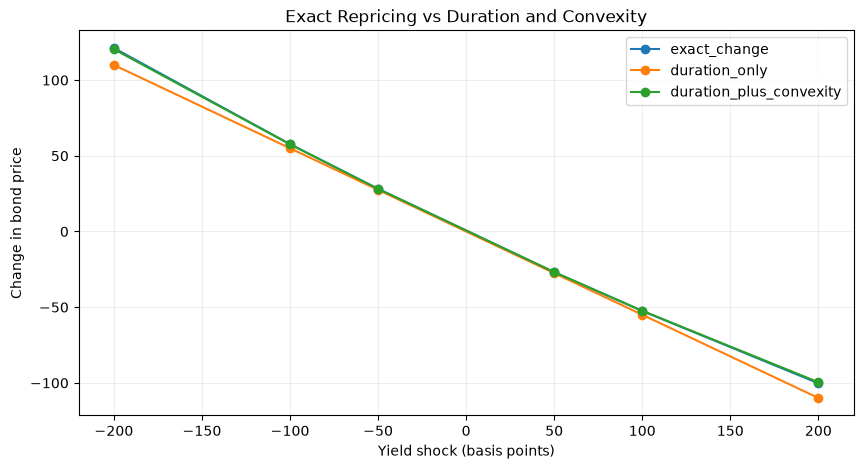

In [7]:
ax = shock_table.plot(figsize=(10,5), marker="o",
                      title="Exact Repricing vs Duration and Convexity")
ax.set_xlabel("Yield shock (basis points)")
ax.set_ylabel("Change in bond price")
ax.grid(alpha=0.2)
plt.show()

## 6. Real U.S. Treasury yield curve

The project downloads U.S. Treasury constant-maturity yields from FRED for

$$
1M,\ 3M,\ 6M,\ 1Y,\ 2Y,\ 5Y,\ 10Y,\ 20Y,\ 30Y.
$$

These are used as an observed term-structure proxy.

**Important:** Treasury constant-maturity yields are not identical to zero-coupon spot rates. Forward-rate calculations that treat them as spot-rate proxies are therefore educational approximations rather than a bootstrapped curve.

In [8]:
FRED_SERIES = {
    "1M": ("DGS1MO", 1/12),
    "3M": ("DGS3MO", 3/12),
    "6M": ("DGS6MO", 6/12),
    "1Y": ("DGS1", 1.0),
    "2Y": ("DGS2", 2.0),
    "5Y": ("DGS5", 5.0),
    "10Y": ("DGS10", 10.0),
    "20Y": ("DGS20", 20.0),
    "30Y": ("DGS30", 30.0),
}

def load_fred_series(series_id, label):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url, na_values=".")
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.rename(columns={date_col: "date", series_id: label})
    return df.set_index("date")[[label]]

treasury_frames = [
    load_fred_series(series_id, label)
    for label, (series_id, maturity) in FRED_SERIES.items()
]

treasury_history = pd.concat(treasury_frames, axis=1).sort_index()
complete = treasury_history.dropna()
latest_curve_row = complete.iloc[-1]
latest_curve_date = complete.index[-1]

curve = pd.DataFrame({
    "maturity_label": list(FRED_SERIES.keys()),
    "maturity_years": [x[1] for x in FRED_SERIES.values()],
    "yield_percent": [latest_curve_row[label] for label in FRED_SERIES.keys()],
})

print("Latest common observation:", latest_curve_date.date())
curve

Latest common observation: 2026-09-17


,maturity_label,maturity_years,yield_percent
0,1M,0.083333,3.970000
1,3M,0.250000,4.120000
2,6M,0.500000,4.200000
3,1Y,1.000000,4.400000
4,2Y,2.000000,4.670000
5,5Y,5.000000,4.780000
6,10Y,10.000000,4.940000
7,20Y,20.000000,5.320000
8,30Y,30.000000,5.290000


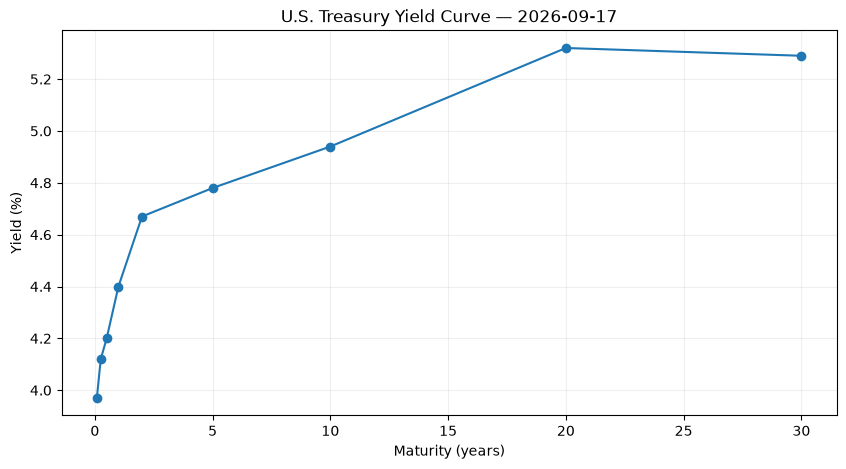

In [9]:
plt.figure(figsize=(10,5))
plt.plot(curve["maturity_years"], curve["yield_percent"], marker="o")
plt.title(f"U.S. Treasury Yield Curve — {latest_curve_date.date()}")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.grid(alpha=0.2)
plt.show()

## 7. Forward rates

For continuously compounded zero rates,

$$
\boxed{f(T_1,T_2)=\frac{R(T_2)T_2-R(T_1)T_1}{T_2-T_1}}.
$$

The course also gives the bond-price relation

$$
F(t,T,S)=\frac{1}{S-T}\ln\left(\frac{P(t,T)}{P(t,S)}\right)
$$

and the instantaneous forward rate

$$
\boxed{f(t,T)=-\frac{\partial}{\partial T}\ln P(t,T)}.
$$

In [10]:
curve_sorted = curve.sort_values("maturity_years").reset_index(drop=True)
curve_sorted["yield_decimal"] = curve_sorted["yield_percent"] / 100

forward_rows=[]
for i in range(len(curve_sorted)-1):
    T1 = curve_sorted.loc[i, "maturity_years"]
    T2 = curve_sorted.loc[i+1, "maturity_years"]
    R1 = curve_sorted.loc[i, "yield_decimal"]
    R2 = curve_sorted.loc[i+1, "yield_decimal"]
    fwd = (R2*T2 - R1*T1) / (T2 - T1)
    forward_rows.append({
        "from": curve_sorted.loc[i, "maturity_label"],
        "to": curve_sorted.loc[i+1, "maturity_label"],
        "forward_rate_percent": 100*fwd,
    })

forward_curve = pd.DataFrame(forward_rows)
forward_curve

,from,to,forward_rate_percent
0,1M,3M,4.195000
1,3M,6M,4.280000
2,6M,1Y,4.600000
3,1Y,2Y,4.940000
4,2Y,5Y,4.853333
5,5Y,10Y,5.100000
6,10Y,20Y,5.700000
7,20Y,30Y,5.230000


## 8. Nelson--Siegel family from the course

The lecture introduces

$$
\boxed{f_{NS}(\tau;z)=z_1+(z_2+z_3\tau)e^{-z_4\tau}}
$$

with $\tau=T-t$.

We estimate the four parameters by nonlinear least squares.

In [11]:
def nelson_siegel_course(tau, z1, z2, z3, z4):
    tau = np.asarray(tau, dtype=float)
    return z1 + (z2 + z3*tau) * np.exp(-z4*tau)

tau = curve["maturity_years"].to_numpy(dtype=float)
y_obs = curve["yield_percent"].to_numpy(dtype=float) / 100

initial = np.array([y_obs[-1], y_obs[0]-y_obs[-1], 0.0, 0.5])

def residuals(params):
    return nelson_siegel_course(tau, *params) - y_obs

fit = least_squares(
    residuals,
    initial,
    bounds=(np.array([-0.20,-0.50,-0.50,1e-6]),
            np.array([ 0.30, 0.50, 0.50,10.0]))
)

z1, z2, z3, z4 = fit.x
pd.Series({
    "z1": z1,
    "z2": z2,
    "z3": z3,
    "z4": z4,
    "RMSE_bps": 10000*np.sqrt(np.mean(residuals(fit.x)**2)),
}).to_frame("estimate")

,estimate
z1,0.052548
z2,-0.011719
z3,-0.000000
z4,0.211173
RMSE_bps,10.717624


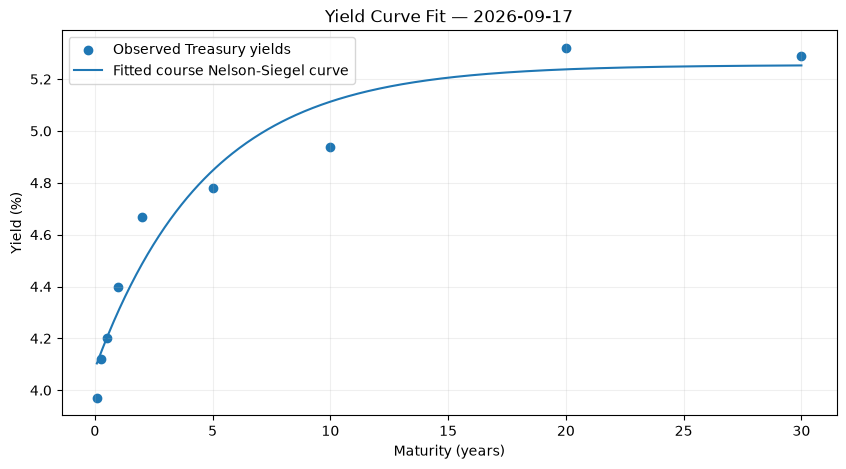

In [12]:
tau_dense = np.linspace(tau.min(), tau.max(), 500)
y_fit = nelson_siegel_course(tau_dense, z1, z2, z3, z4)

plt.figure(figsize=(10,5))
plt.scatter(tau, 100*y_obs, label="Observed Treasury yields")
plt.plot(tau_dense, 100*y_fit, label="Fitted course Nelson-Siegel curve")
plt.title(f"Yield Curve Fit — {latest_curve_date.date()}")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 9. Current-curve bond risk experiment

We use the latest observed 10-year Treasury constant-maturity yield as the base yield for a **hypothetical** 10-year coupon bond.

This isolates interest-rate risk while keeping the market yield level real.

In [13]:
latest_10y_yield = float(
    curve.loc[curve["maturity_label"] == "10Y", "yield_percent"].iloc[0]
) / 100

face = 1000
coupon_rate = 0.04
maturity = 10
y0 = latest_10y_yield

P0 = bond_price(face, coupon_rate, maturity, y0)
D = macaulay_duration(face, coupon_rate, maturity, y0)
Dm = modified_duration(face, coupon_rate, maturity, y0)
C = convexity(face, coupon_rate, maturity, y0)

pd.Series({
    "base_10Y_yield": y0,
    "bond_price": P0,
    "Macaulay_duration": D,
    "Modified_duration": Dm,
    "Convexity": C,
}).to_frame("value")

,value
base_10Y_yield,0.049400
bond_price,927.203732
Macaulay_duration,8.364200
Modified_duration,7.970460
Convexity,78.440363


In [14]:
scenario_rows=[]
for bps in [-200,-100,-50,0,50,100,200]:
    dy = bps/10000
    scenario_rows.append({
        "yield_shock_bps": bps,
        "exact_price": bond_price(face,coupon_rate,maturity,y0+dy),
        "duration_price": P0 - Dm*P0*dy,
        "duration_convexity_price": P0 - Dm*P0*dy + 0.5*C*P0*dy**2,
    })

scenario_table = pd.DataFrame(scenario_rows).set_index("yield_shock_bps")
scenario_table

,exact_price,duration_price,duration_convexity_price
yield_shock_bps,,,
-200,"1,090.697652","1,075.008532","1,089.554571"
-100,"1,004.881106","1,001.106132","1,004.742642"
-50,965.081102,964.154932,965.064060
0,927.203732,927.203732,927.203732
50,891.145127,890.252532,891.161660
100,856.807543,853.301332,856.937842
200,792.932775,779.398933,793.944972


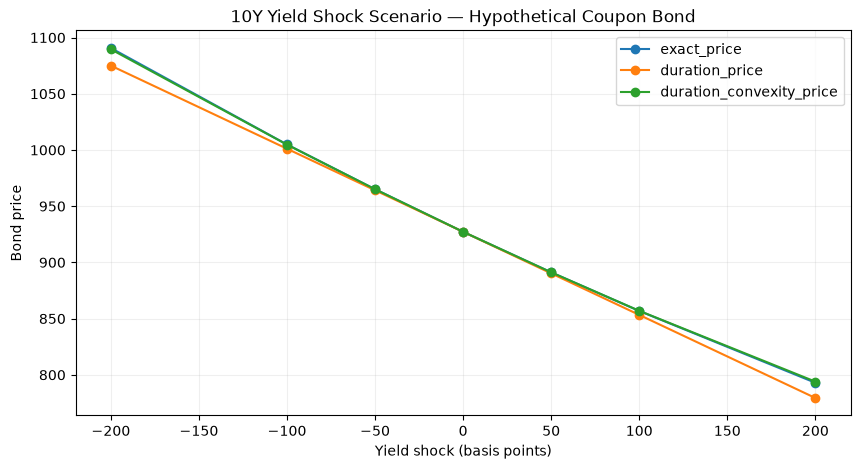

In [15]:
ax = scenario_table.plot(figsize=(10,5), marker="o",
                         title="10Y Yield Shock Scenario — Hypothetical Coupon Bond")
ax.set_xlabel("Yield shock (basis points)")
ax.set_ylabel("Bond price")
ax.grid(alpha=0.2)
plt.show()

## 10. Vasicek short-rate model

The Vasicek model is based on an Ornstein--Uhlenbeck short rate:

$$
\boxed{dr_t=a(b-r_t)dt+\sigma dW_t}.
$$

The zero-coupon bond price takes the exponential-affine form

$$
\boxed{P(t,T)=\exp(A(\tau)-B(\tau)r_t)},\qquad \tau=T-t,
$$

with

$$
B(\tau)=\frac{1-e^{-a\tau}}{a},
$$

and the course closed-form loading

$$
A(\tau)=(B(\tau)-\tau)\left(b-\frac{\sigma^2}{2a^2}\right)-\frac{\sigma^2}{4a}B(\tau)^2.
$$

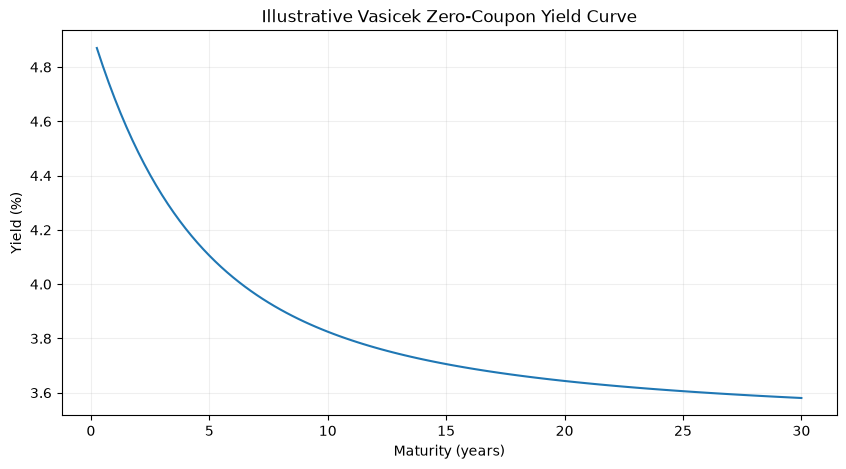

In [16]:
def vasicek_B(tau, a):
    return (1 - np.exp(-a*tau)) / a

def vasicek_A(tau, a, b, sigma):
    B = vasicek_B(tau, a)
    return (B-tau)*(b - sigma**2/(2*a**2)) - (sigma**2/(4*a))*B**2

def vasicek_zero_coupon_price(r0, tau, a, b, sigma):
    A = vasicek_A(tau, a, b, sigma)
    B = vasicek_B(tau, a)
    return np.exp(A - B*r0)

r0 = latest_10y_yield
a = 0.40
b = 0.035
sigma_r = 0.012

vas_maturities = np.linspace(0.25, 30, 120)
vas_prices = np.array([vasicek_zero_coupon_price(r0,T,a,b,sigma_r) for T in vas_maturities])
vas_yields = -np.log(vas_prices)/vas_maturities

plt.figure(figsize=(10,5))
plt.plot(vas_maturities, 100*vas_yields)
plt.title("Illustrative Vasicek Zero-Coupon Yield Curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.grid(alpha=0.2)
plt.show()

The Vasicek parameters above are **illustrative**, not live calibrated estimates. The purpose is to show how a stochastic short-rate model generates a full zero-coupon curve.

## 11. Cox--Ingersoll--Ross (CIR) model

The CIR model is

$$
\boxed{dr_t=a(b-r_t)dt+\sigma\sqrt{r_t}\,dW_t}.
$$

Let

$$
\gamma=\sqrt{a^2+2\sigma^2}.
$$

The lecture again gives

$$
P(t,T)=\exp(A(\tau)-B(\tau)r_t),
$$

with

$$
B(\tau)=\frac{2(e^{\gamma\tau}-1)}{(\gamma+a)(e^{\gamma\tau}-1)+2\gamma}.
$$

The course's $A(\tau)$ is the logarithm of the multiplicative loading.

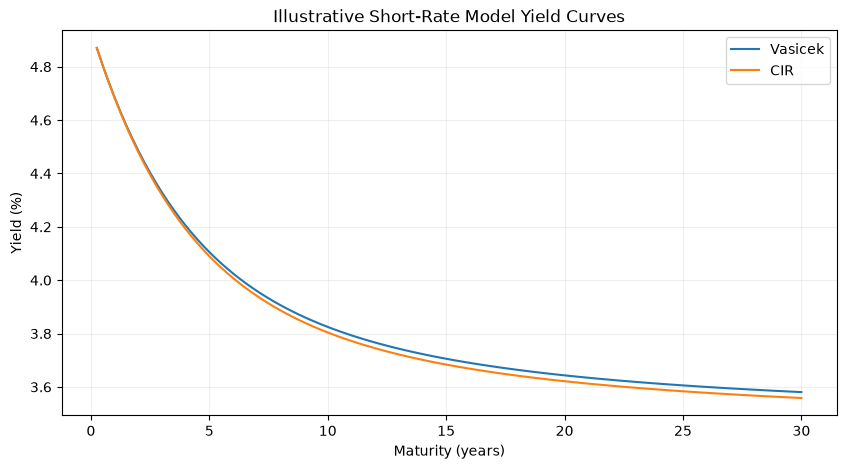

In [17]:
def cir_B(tau, a, sigma):
    gamma = np.sqrt(a**2 + 2*sigma**2)
    eg = np.exp(gamma*tau)
    return 2*(eg-1)/((gamma+a)*(eg-1)+2*gamma)

def cir_log_A(tau, a, b, sigma):
    gamma = np.sqrt(a**2 + 2*sigma**2)
    eg = np.exp(gamma*tau)
    numerator = 2*gamma*np.exp((gamma+a)*tau/2)
    denominator = (gamma+a)*(eg-1)+2*gamma
    return (2*a*b/sigma**2) * np.log(numerator/denominator)

def cir_zero_coupon_price(r0, tau, a, b, sigma):
    return np.exp(cir_log_A(tau,a,b,sigma) - cir_B(tau,a,sigma)*r0)

cir_a = 0.40
cir_b = 0.035
cir_sigma = 0.08

cir_prices = np.array([cir_zero_coupon_price(r0,T,cir_a,cir_b,cir_sigma) for T in vas_maturities])
cir_yields = -np.log(cir_prices)/vas_maturities

plt.figure(figsize=(10,5))
plt.plot(vas_maturities, 100*vas_yields, label="Vasicek")
plt.plot(vas_maturities, 100*cir_yields, label="CIR")
plt.title("Illustrative Short-Rate Model Yield Curves")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 12. What this project demonstrates

1. Bond cash-flow valuation.
2. Numerical Yield to Maturity via Newton--Raphson.
3. Zero-coupon pricing and continuous discounting.
4. Macaulay and modified duration.
5. Convexity and nonlinear price sensitivity.
6. Exact repricing versus duration and duration-plus-convexity approximations.
7. A real U.S. Treasury term-structure snapshot.
8. Approximate forward-rate extraction.
9. Parametric curve fitting with the Nelson--Siegel family used in the course.
10. A real-market 10Y yield shock experiment.
11. Vasicek and CIR short-rate models.

$$
\boxed{\text{Fixed-income risk is fundamentally linked to the evolution of yields.}}
$$

## 13. Limitations

- Treasury constant-maturity yields are not a bootstrapped zero-coupon curve.
- Forward rates computed from them are approximations.
- Coupon-bond shock experiments use hypothetical contracts.
- Vasicek and CIR parameters are illustrative rather than live calibrated estimates.
- Credit, liquidity, inflation, taxes and transaction costs are outside the current scope.
- Nothing in this notebook constitutes investment advice.